# Market Movement Prediction using ML

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from utils.read_prices import read_parquet

In [2]:
df = read_parquet()
df.head()

,Close,High,Low,Open,Volume,interest_rate,returns,log_returns
Date,,,,,,,,
2016-01-01,434.334015,436.246002,427.515015,430.721008,36278900,0.20,NaN,NaN
2016-01-02,433.437988,436.062012,431.869995,434.622009,30096600,0.20,0.997937,-0.002065
2016-01-03,430.010986,433.743011,424.705994,433.578003,39633800,0.20,0.992093,-0.007938
2016-01-04,433.091003,434.516998,429.084015,430.061005,38477500,0.36,1.007163,0.007137
2016-01-05,431.959991,434.182007,429.675995,433.069000,34522600,0.36,0.997389,-0.002615


In [3]:
df = df[['Close', 'Volume', 'interest_rate', 'returns', 'log_returns']]

In [4]:
df['volatility'] = df['Close'].rolling(20).std()

In [5]:
lag_cols = []
for lag in range(1,6):
    col = f"lag_{lag}"
    df[col] = df['log_returns'].shift(lag)
    lag_cols.append(col)
df.dropna(inplace=True)

In [6]:
df['direction'] = np.where(df['log_returns'] > 0, 1, -1)
# df['direction'] = np.where(df['return'] < 0, -1, df['return'])

In [7]:
df['direction'].value_counts()

direction
 1    1010
-1     797
Name: count, dtype: int64

In [8]:
lag_cols = ['lag_5', 'lag_4', 'lag_3', 'lag_2', 'lag_1']

y_train = df['direction'].loc[:'2019-12-31']
y_test = df['direction'].loc['2020-01-01':]
df_ = df.drop(labels=['direction', 'returns', 'log_returns'], axis=1)
X_train = df_[lag_cols].loc[:'2019-12-31']
X_test = df_[lag_cols].loc['2020-01-01':]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1442, 5), (365, 5), (1442,), (365,))

## Logistic Regression

In [9]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    C=100000,
    random_state=490,
    max_iter=1000,
    n_jobs=-1
    )

lr.fit(X_train, y_train)

LogisticRegression(C=100000, max_iter=1000, n_jobs=-1, random_state=490)

In [10]:
preds = lr.predict(X_test)

score = lr.score(X_test, y_test)

print(f"Score: {score}")

Score: 0.5561643835616439


In [11]:
pd.Series(preds).value_counts()

 1    361
-1      4
Name: count, dtype: int64

In [12]:
strategy = pd.Series(preds, index=df.loc['2020-01-01':].index) * df['log_returns'].loc['2020-01-01':]

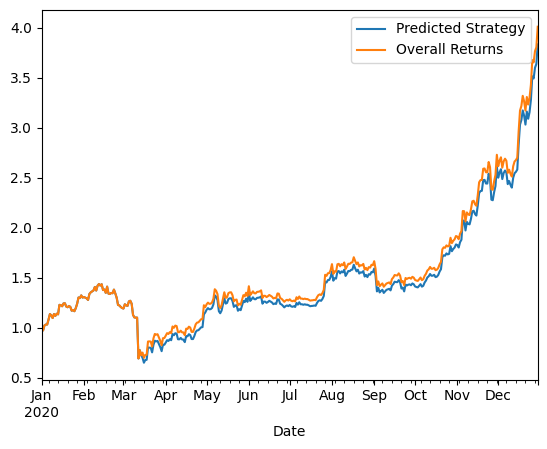

In [13]:
np.exp(strategy.cumsum()).plot(kind='line', label='Predicted Strategy')
np.exp(df['log_returns'].loc['2020-01-01':].cumsum()).plot(kind='line', label='Overall Returns')
plt.legend()
plt.show()

### using volatility and volume

In [14]:
new_cols = ['Volume', 'Close', 'interest_rate'] + lag_cols
X_train_total = df[new_cols].loc[:'2019-12-31']
X_test_total = df[new_cols].loc['2020-01-01':]

X_train_total.shape, X_test_total.shape, y_train.shape, y_test.shape

((1442, 8), (365, 8), (1442,), (365,))

In [15]:
lr_2 = LogisticRegression(C=100000,
                          random_state=490,
                          max_iter=1000,
                          n_jobs=-1)

lr_2.fit(X_train_total, y_train)

LogisticRegression(C=100000, max_iter=1000, n_jobs=-1, random_state=490)

In [16]:
lr_2_preds = lr_2.predict(X_test_total)

score = lr_2.score(X_test_total, y_test)

print(f"Score: {score}")

Score: 0.5616438356164384


In [17]:
strategy_2 = pd.Series(lr_2_preds, index=df.loc['2020-01-01':].index) * df['log_returns'].loc['2020-01-01':]

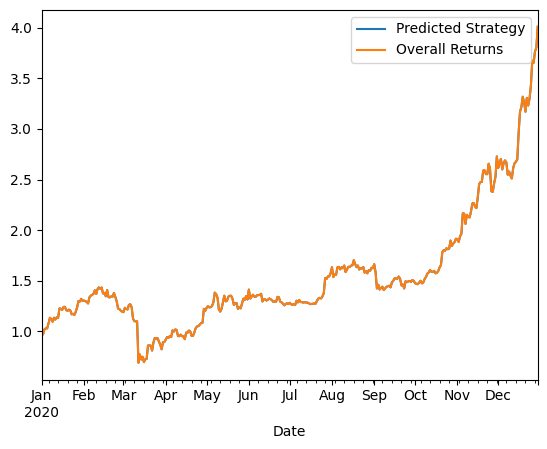

In [18]:
np.exp(strategy_2.cumsum()).plot(kind='line', label='Predicted Strategy')
np.exp(df['log_returns'].loc['2020-01-01':].cumsum()).plot(kind='line', label='Overall Returns')
plt.legend()
plt.show()

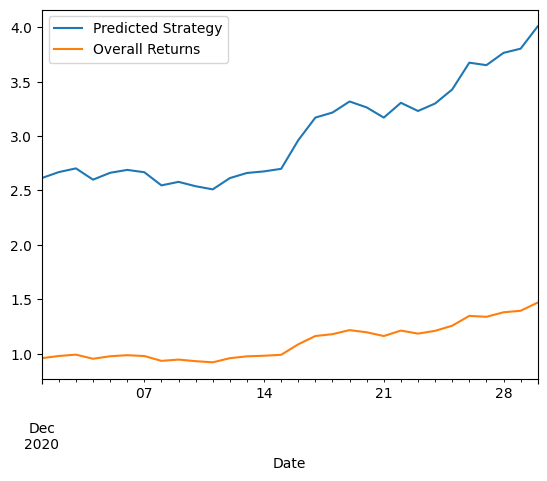

In [24]:
np.exp(strategy_2.cumsum()).loc['2020-12-01':'2020-12-31'].plot(kind='line', label='Predicted Strategy')
np.exp(df['log_returns'].loc['2020-12-01':'2020-12-31'].cumsum()).plot(kind='line', label='Overall Returns')
plt.legend()
plt.show()

In [25]:
coeff_df = pd.DataFrame(
    {'Coefficients': lr_2.coef_[0]},
    index=new_cols)

coeff_df

,Coefficients
Volume,5.962162e-12
Close,3.575211e-17
interest_rate,1.246538e-20
lag_5,7.922483e-23
lag_4,3.159225e-23
lag_3,2.420092e-22
lag_2,1.817531e-23
lag_1,-2.333705e-22


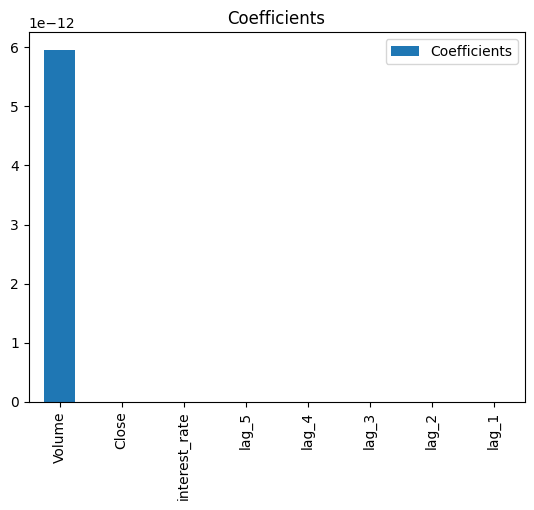

In [26]:
coeff_df.plot(kind='bar', title='Coefficients')
plt.show()

## Deep Learning

In [ ]:
torch.manual_seed(490)

In [ ]:
X_train_rnn = X_train.to_numpy().reshape((-1,5,1))
X_test_rnn = X_test.to_numpy().reshape((-1,5,1))

In [ ]:
X_train_rnn = torch.tensor(X_train_rnn.astype(np.float32))
X_test_rnn = torch.tensor(X_test_rnn.astype(np.float32))
y_train_rnn = torch.tensor(y_train.astype(np.float32))
y_test_rnn = torch.tensor(y_test.astype(np.float32))

/var/folders/ly/yp55phj14sggk71834drw0d80000gn/T/ipykernel_78524/4172938690.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train_rnn = torch.tensor(y_train.astype(np.float32))
/var/folders/ly/yp55phj14sggk71834drw0d80000gn/T/ipykernel_78524/4172938690.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_test_rnn = torch.tensor(y_test.astype(np.float32))


In [ ]:
import torch.nn as nn
from torch.utils.data import TensorDataset

class BTC(nn.Module):
    def __init__(self):
        super(BTC, self).__init__()
        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=12,
            num_layers=2,
            nonlinearity='relu'
            )
        self.linear = nn.Linear(
            in_features=12,
            out_features=1
        )
        self.dropout = nn.Dropout(.10)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        val, h_n = self.rnn(x)
        val = self.linear(self.dropout(val[:, -1]))
        return self.sigmoid(torch.flatten(val))

In [ ]:
train_datasets = TensorDataset(X_train_rnn, y_train_rnn)
test_datasets = TensorDataset(X_test_rnn, y_test_rnn)

In [ ]:
next(iter(train_datasets))

(tensor([[-0.1664],
         [ 0.0617],
         [-0.0136],
         [ 0.0127],
         [-0.0183]]),
 tensor(1.))

In [ ]:
X_test_rnn.shape

torch.Size([365, 5, 1])

In [ ]:
from torchinfo import summary

btc_model = BTC()

summary(btc_model,
        input_data=X_test_rnn,
        col_names=['input_size',
                   'output_size',
                   'num_params']
                   )

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
BTC                                      [365, 5, 1]               [365]                     --
├─RNN: 1-1                               [365, 5, 1]               [365, 5, 12]              492
├─Dropout: 1-2                           [365, 12]                 [365, 12]                 --
├─Linear: 1-3                            [365, 12]                 [365, 1]                  13
├─Sigmoid: 1-4                           [365]                     [365]                     --
Total params: 505
Trainable params: 505
Non-trainable params: 0
Total mult-adds (M): 0.90
Input size (MB): 0.01
Forward/backward pass size (MB): 0.18
Params size (MB): 0.00
Estimated Total Size (MB): 0.19

In [ ]:
from torch.utils.data import DataLoader

In [ ]:
train_dataloader = DataLoader(train_datasets,
                              batch_size=16,
                              shuffle=False)

test_dataloader = DataLoader(test_datasets,
                             batch_size=16,
                             shuffle=False)

In [ ]:
for i, (x, y) in list(enumerate(train_dataloader)):
    out = btc_model(x)
    print(y.size(), out.size())
    if i >= 2:
        break

torch.Size([16]) torch.Size([16])
torch.Size([16]) torch.Size([16])
torch.Size([16]) torch.Size([16])


In [ ]:
optim = torch.optim.AdamW(btc_model.parameters(), lr=.001)
loss_fn = nn.BCEWithLogitsLoss()

In [ ]:
def accuracy_fn(y_true, y_preds):
  correct = torch.eq(y_true, y_preds).sum().item()
  acc = (correct/len(y_preds)) * 100
  return acc

In [ ]:
len(next(iter(train_dataloader)))

2

In [ ]:
with torch.inference_mode():
    for batch, (X, y) in list(enumerate(train_dataloader)):
        preds = btc_model(X)
preds, y

(tensor([0.5637, 0.5758]), tensor([-1., -1.]))

In [ ]:
train_accs = []
test_accs = []

for epoch in range(100):
    train_loss = 0
    for batch, (X, y) in list(enumerate(train_dataloader)):
        btc_model.train()

        y_pred = btc_model(X)

        loss = loss_fn(y_pred, y)

        optim.zero_grad()

        loss.backward()

        optim.step()

    train_loss /= len(train_dataloader)
    train_acc = accuracy_fn(y, y_pred)
    train_accs.append(train_acc)

    ########################### validation ###############
    test_loss = 0
    # test_acc = 0
    btc_model.eval()
    with torch.inference_mode():
        for X, y in list(test_dataloader):
            test_pred = btc_model(X)

            test_loss += loss_fn(test_pred, y)
            test_acc = accuracy_fn(y, test_pred)
            test_accs.append(test_acc)

        test_loss /= len(test_dataloader)
        # test_acc /= len(test_dataloader)

    if epoch % 10 == 0:
        print(f"Epoch: {epoch}")
        print(f"Train Acc: {np.mean(train_accs)} || Test Acc: {np.mean(test_accs)}\n")

Epoch: 0
Train Acc: 0.0 || Test Acc: 0.0

Epoch: 10
Train Acc: 0.0 || Test Acc: 0.0

Epoch: 20
Train Acc: 0.0 || Test Acc: 0.0

Epoch: 30
Train Acc: 0.0 || Test Acc: 0.0

Epoch: 40
Train Acc: 0.0 || Test Acc: 0.0

Epoch: 50
Train Acc: 0.0 || Test Acc: 0.0

Epoch: 60
Train Acc: 0.0 || Test Acc: 0.0

Epoch: 70
Train Acc: 0.0 || Test Acc: 0.0

Epoch: 80
Train Acc: 0.0 || Test Acc: 0.0

Epoch: 90
Train Acc: 0.0 || Test Acc: 0.0



In [ ]:
# import sklearn
# from sklearn.preprocessing import StandardScaler

# X = pd.DataFrame(StandardScaler(
#     with_mean=True,
#     with_std=True
# ).fit_transform(df),
# columns=['Close', 'Volume', 'Volatility'],
# index=df.index)

In [ ]:
# for lag in range(1,6):
#     for col in X.columns:
#         newcol = np.zeros(X.shape[0]) * np.nan
#         newcol[lag:] = X[col].values[:-lag]
#         X.insert(len(X.columns), f"{col}_{lag}", newcol)

# X
# X.insert(len(X.columns), column= , value=)
# X = X.dropna()